> Optional: the final UMAP cell requires `umap-learn`. If it is not already installed in this kernel, run `%pip install umap-learn` manually. The PCA and all model validations do not require it.


# Continual Trajectory-Tracking Validation

This notebook is evaluation-only. It restores a continual trajectory-tracking checkpoint containing the policy, recurrent encoder, and 9-D residual-dynamics model; collects fresh held-out wind-disturbed figure-eight rollouts; and evaluates:

1. policy tracking error relative to each rollout's time-varying reference;
2. recursive five-second open-loop residual dynamics using the recorded actions, simulator states, delay buffers, and random keys;
3. the encoder latent space, using wind labels only for visualization.

No parameters are updated and validation data never enter training, normalization, checkpoint selection based on performance, or model updates.


In [13]:
import gc
import os
from pathlib import Path

import numpy as np
import yaml

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
import jax.numpy as jnp
from jax.scipy.spatial.transform import Rotation
from matplotlib import pyplot as plt
from orbax.checkpoint import PyTreeCheckpointer

from lotf import LOTF_PATH
from lotf.envs import TrajTrackingStateEnv
from lotf.envs.wrappers import MinMaxObservationWrapper
from lotf.modules import (
    LatentConditionedResidualDynamics,
    MLP,
    RecurrentTrajectoryEncoder,
)
from lotf.objects import Quadrotor, RefTrajNames, TrajColumns

%matplotlib inline


## 1. Validation configuration

By default, `run_name = None` selects the newest trajectory-tracking run directory and `checkpoint_round = None` selects its latest saved round. Set either value explicitly to evaluate a particular run or round. Model dimensions and timing parameters are read from `config/traj_tracking.yaml`.


In [14]:
seed = 2026
master_key = jax.random.key(seed)


def experiment_key(stream_id):
    return jax.random.fold_in(master_key, stream_id)


configuration_path = Path(os.path.abspath(os.path.join(
    LOTF_PATH, "..", "config", "traj_tracking.yaml"
)))
with configuration_path.open("r", encoding="utf-8") as stream:
    experiment_configuration = yaml.safe_load(stream)

dataset_config = experiment_configuration["shared_context_dataset"]
policy_config = experiment_configuration["policy_optimization"]

# Leave these as None to select the newest available trajectory checkpoint.
run_name = None
checkpoint_round = None
continual_checkpoint_base = Path(os.path.abspath(os.path.join(
    LOTF_PATH,
    "..",
    "checkpoints",
    "continual_vnd",
    "traj_tracking_full",
)))

validation_num_rollouts = 32
open_loop_validation_time = 5.0
last_policy_window_seconds = 3.0
max_policy_trajectory_plots = 8
max_open_loop_trajectory_plots = 16
encoder_evaluation_batch_size = 512

context_length = int(dataset_config["context_length"])
latent_dim = int(dataset_config["latent_dim"])
state_action_dim = int(dataset_config["state_action_dim"])
residual_dim = int(dataset_config["residual_dim"])
sim_dt = 0.02
control_delay = 0.04
reference_trajectory = RefTrajNames.FIG8

open_loop_horizon = int(round(open_loop_validation_time / sim_dt))
validation_num_steps = context_length + open_loop_horizon
validation_duration = validation_num_steps * sim_dt

assert context_length == 20
assert state_action_dim == 14
assert residual_dim == 9
assert validation_num_rollouts > 0
assert open_loop_horizon > 0
assert last_policy_window_seconds > 0
assert last_policy_window_seconds <= validation_duration
assert int(policy_config["policy_rollout_horizon"]) == 125

print(f"Configuration: {configuration_path}")
print(f"Fresh validation rollouts: {validation_num_rollouts}")
print(
    f"Collected duration: {validation_duration:.2f} s "
    f"({validation_num_steps} steps)"
)
print(f"Residual open-loop horizon: {open_loop_validation_time:.2f} s")


Configuration: /home/dimitria/PhD_codes/learning_on_the_fly/config/traj_tracking.yaml
Fresh validation rollouts: 32
Collected duration: 5.40 s (270 steps)
Residual open-loop horizon: 5.00 s


## 2. Recreate the tracking environments and model modules

The disturbed environment generates held-out figure-eight trajectories with one hidden wind acceleration fixed throughout each rollout. The nominal environment has the identical reference, simulator configuration, reset distribution, action limits, and 0.04 s control delay, but applies no hidden wind; it is used only for recursive residual-dynamics validation.


In [15]:
nominal_dynamics_configuration = {
    "use_high_fidelity": False,
    "use_forward_residual": False,
}
quadrotor = Quadrotor.from_name(
    "example_quad", nominal_dynamics_configuration
)


def make_tracking_environment(apply_hidden_acceleration):
    environment = TrajTrackingStateEnv(
        max_steps_in_episode=validation_num_steps,
        dt=sim_dt,
        delay=control_delay,
        quad_obj=quadrotor,
        ref_traj_name=reference_trajectory,
        skip_start=True,
        apply_hidden_acceleration=apply_hidden_acceleration,
    )
    return MinMaxObservationWrapper(environment)


validation_env = make_tracking_environment(
    apply_hidden_acceleration=True
)
nominal_env = make_tracking_environment(
    apply_hidden_acceleration=False
)

obs_dim = validation_env.observation_space.shape[0]
action_dim = validation_env.action_space.shape[0]
dummy_residual_params = {}

trajectory_encoder = RecurrentTrajectoryEncoder(
    state_action_dim=state_action_dim,
    context_length=context_length,
    latent_dim=latent_dim,
    projection_dim=128,
    hidden_dim=128,
)
residual_model = LatentConditionedResidualDynamics(
    state_action_dim=state_action_dim,
    latent_dim=latent_dim,
    hidden_dim=256,
    num_blocks=2,
    predict_orientation=True,
)
latent_policy_net = MLP(
    [obs_dim + latent_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=validation_env.hovering_action,
)

print(f"Reference trajectory:   {reference_trajectory.value}")
print(f"Observation dimension:  {obs_dim}")
print(f"Action dimension:       {action_dim}")
print(f"Residual dimension:     {residual_dim}")
print(f"Control delay:          {control_delay:.3f} s")


Reference trajectory:   fig8
Observation dimension:  27
Action dimension:       4
Residual dimension:     9
Control delay:          0.040 s


## 3. Restore the continual trajectory-tracking checkpoint

Only the final policy, encoder, residual parameters, and normalization statistics are retained. Optimizer states and the decoder are released because validation never performs an update.


In [16]:
if not continual_checkpoint_base.is_dir():
    raise FileNotFoundError(
        f"Trajectory checkpoint directory does not exist: "
        f"{continual_checkpoint_base}"
    )


def completed_checkpoint_directories(run_directory):
    return [
        path for path in run_directory.glob("round_*")
        if (
            path.is_dir()
            and (path / "_CHECKPOINT_METADATA").is_file()
            and (path / "manifest.ocdbt").is_file()
        )
    ]


if run_name is None:
    run_candidates = sorted(
        path for path in continual_checkpoint_base.glob("run_*")
        if path.is_dir() and completed_checkpoint_directories(path)
    )
    if not run_candidates:
        raise FileNotFoundError(
            f"No trajectory-tracking runs found under "
            f"{continual_checkpoint_base}"
        )
    continual_checkpoint_root = run_candidates[-1]
else:
    continual_checkpoint_root = continual_checkpoint_base / run_name
    if not continual_checkpoint_root.is_dir():
        raise FileNotFoundError(
            f"Trajectory run does not exist: {continual_checkpoint_root}"
        )

checkpoint_candidates = sorted(
    completed_checkpoint_directories(continual_checkpoint_root),
    key=lambda path: int(path.name.split("_")[-1]),
)
if not checkpoint_candidates:
    raise FileNotFoundError(
        f"No continual checkpoints found under {continual_checkpoint_root}"
    )

if checkpoint_round is None:
    continual_checkpoint_path = checkpoint_candidates[-1]
else:
    continual_checkpoint_path = (
        continual_checkpoint_root / f"round_{checkpoint_round:04d}"
    )
    if continual_checkpoint_path not in checkpoint_candidates:
        raise FileNotFoundError(
            f"Checkpoint does not exist: {continual_checkpoint_path}"
        )

restored_checkpoint = PyTreeCheckpointer().restore(
    str(continual_checkpoint_path)
)


def extract_params(saved_train_state):
    if hasattr(saved_train_state, "params"):
        return saved_train_state.params
    if isinstance(saved_train_state, dict) and "params" in saved_train_state:
        return saved_train_state["params"]
    raise TypeError(
        "Expected a restored TrainState or a dictionary containing 'params'"
    )


restored_joint_params = extract_params(
    restored_checkpoint["joint_train_state"]
)
policy_params = extract_params(restored_checkpoint["policy_train_state"])
input_mean = restored_checkpoint["input_mean"]
input_std = restored_checkpoint["input_std"]
residual_target_mean = restored_checkpoint["residual_target_mean"]
residual_target_std = restored_checkpoint["residual_target_std"]
completed_rounds = int(jax.device_get(
    restored_checkpoint["completed_rounds"]
))


def tree_is_finite(tree):
    return all(
        bool(jax.device_get(jnp.all(jnp.isfinite(leaf))))
        for leaf in jax.tree.leaves(tree)
    )


if set(restored_joint_params) != {"encoder", "residual", "decoder"}:
    raise ValueError(
        "The joint checkpoint must contain encoder, residual, and decoder "
        "parameter groups"
    )
if input_mean.shape != (state_action_dim,):
    raise ValueError(f"Expected {state_action_dim}-D input statistics")
if residual_target_mean.shape != (residual_dim,):
    raise ValueError(f"Expected {residual_dim}-D residual statistics")
if not tree_is_finite(policy_params):
    raise ValueError(
        "The restored policy contains NaN or Inf parameters. Select a clean "
        "checkpoint rather than one saved after policy corruption."
    )
joint_params = {
    "encoder": restored_joint_params["encoder"],
    "residual": restored_joint_params["residual"],
}
if not tree_is_finite(joint_params):
    raise ValueError("The restored encoder or residual parameters are non-finite")

# Release the unused decoder and optimizer states retained by the checkpoint.
del restored_joint_params, restored_checkpoint
gc.collect()

dummy_context = jnp.zeros(
    (1, context_length, state_action_dim), dtype=jnp.float32
)
dummy_latent = trajectory_encoder.apply(
    joint_params["encoder"], dummy_context
)
dummy_residual = residual_model.apply(
    joint_params["residual"],
    jnp.zeros((1, state_action_dim), dtype=jnp.float32),
    dummy_latent,
)
dummy_policy_action = latent_policy_net.apply(
    policy_params,
    jnp.zeros((1, obs_dim + latent_dim), dtype=jnp.float32),
)
assert dummy_latent.shape == (1, latent_dim)
assert dummy_residual.shape == (1, residual_dim)
assert dummy_policy_action.shape == (1, action_dim)

print(f"Loaded checkpoint: {continual_checkpoint_path}")
print(f"Completed continual rounds: {completed_rounds}")
print(f"Encoder output shape: {dummy_latent.shape}")
print(f"Residual output shape: {dummy_residual.shape}")
print(f"Policy output shape: {dummy_policy_action.shape}")


/home/dimitria/venvs/diff-sim-env/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Loaded checkpoint: /home/dimitria/PhD_codes/learning_on_the_fly/checkpoints/continual_vnd/traj_tracking_full/run_2026-08-28_14-29-02_344009/round_0425
Completed continual rounds: 425
Encoder output shape: (1, 12)
Residual output shape: (1, 9)
Policy output shape: (1, 4)


## 4. State representation and fresh trajectory collection

The deployed policy receives a rolling normalized encoder context after the first 20 transitions. Before the context is full, it receives a zero latent, exactly as in continual training. Validation adds no action excitation. Each rollout retains its sampled figure-eight start index and its episode-constant hidden wind.


In [17]:
def state_vector_from_env_state(env_state):
    quaternion_xyzw = Rotation.from_matrix(
        env_state.quadrotor_state.R
    ).as_quat()
    quaternion_wxyz = jnp.concatenate(
        [quaternion_xyzw[..., 3:], quaternion_xyzw[..., :3]],
        axis=-1,
    )
    return jnp.concatenate([
        env_state.quadrotor_state.p,
        quaternion_wxyz,
        env_state.quadrotor_state.v,
    ], axis=-1)


def normalize_state_actions(raw_state_actions):
    normalized = (raw_state_actions - input_mean) / input_std
    normalized = normalized.at[..., 0:3].set(
        jnp.clip(normalized[..., 0:3], -5.0, 5.0)
    )
    normalized = normalized.at[..., 7:10].set(
        jnp.clip(normalized[..., 7:10], -5.0, 5.0)
    )
    return normalized


def reference_rows_for_states(env_states):
    reference_indices = jnp.minimum(
        env_states.init_ref_traj_idx + env_states.step_idx,
        validation_env._env.num_ref_traj_points - 1,
    )
    return validation_env._env.ref_traj[reference_indices]


def rotation_matrix_from_rotvec(rotation_vector):
    # Zero-angle-safe Rodrigues exponential for recursive orientation updates.
    x, y, z = jnp.moveaxis(rotation_vector, -1, 0)
    zeros = jnp.zeros_like(x)
    skew = jnp.stack([
        zeros, -z, y,
        z, zeros, -x,
        -y, x, zeros,
    ], axis=-1).reshape(rotation_vector.shape[:-1] + (3, 3))
    angle_squared = jnp.sum(jnp.square(rotation_vector), axis=-1)
    safe_angle = jnp.sqrt(jnp.maximum(
        angle_squared, jnp.finfo(rotation_vector.dtype).eps
    ))
    coefficient_a_regular = jnp.sin(safe_angle) / safe_angle
    half_angle = 0.5 * safe_angle
    coefficient_b_regular = 0.5 * jnp.square(
        jnp.sin(half_angle) / half_angle
    )
    coefficient_a_series = (
        1.0 - angle_squared / 6.0 + angle_squared**2 / 120.0
    )
    coefficient_b_series = (
        0.5 - angle_squared / 24.0 + angle_squared**2 / 720.0
    )
    use_series = angle_squared < 1e-4
    coefficient_a = jnp.where(
        use_series, coefficient_a_series, coefficient_a_regular
    )
    coefficient_b = jnp.where(
        use_series, coefficient_b_series, coefficient_b_regular
    )
    identity = jnp.broadcast_to(
        jnp.eye(3, dtype=rotation_vector.dtype), skew.shape
    )
    return (
        identity
        + coefficient_a[..., None, None] * skew
        + coefficient_b[..., None, None] * (skew @ skew)
    )


@jax.jit
def collect_validation_rollouts(collection_key):
    key_reset, key_scan = jax.random.split(collection_key)
    reset_keys = jax.random.split(key_reset, validation_num_rollouts)
    initial_states, initial_observations = jax.vmap(
        validation_env.reset
    )(reset_keys)
    initial_contexts = jnp.zeros(
        (validation_num_rollouts, context_length, state_action_dim),
        dtype=jnp.float32,
    )

    def collection_step(carry, step_key):
        env_states, observations, contexts, context_count = carry
        encoded_latents = trajectory_encoder.apply(
            joint_params["encoder"], contexts
        )
        policy_latents = jnp.where(
            context_count >= context_length,
            encoded_latents,
            jnp.zeros_like(encoded_latents),
        )
        policy_inputs = jnp.concatenate(
            [observations, policy_latents], axis=-1
        )
        actions = latent_policy_net.apply(policy_params, policy_inputs)
        actions = jnp.clip(
            actions,
            validation_env.action_space.low,
            validation_env.action_space.high,
        )

        environment_keys = jax.random.split(
            step_key, validation_num_rollouts
        )
        transitions = jax.vmap(
            lambda state, action, key: validation_env._step(
                state, action, dummy_residual_params, key
            )
        )(env_states, actions, environment_keys)

        raw_state_actions = jnp.concatenate(
            [state_vector_from_env_state(env_states), actions],
            axis=-1,
        )
        normalized_state_actions = normalize_state_actions(
            raw_state_actions
        )
        next_contexts = jnp.roll(contexts, shift=-1, axis=1)
        next_contexts = next_contexts.at[:, -1, :].set(
            normalized_state_actions
        )
        done = jnp.logical_or(
            transitions.terminated, transitions.truncated
        )
        outputs = (
            transitions.state,
            actions,
            done,
            environment_keys,
            policy_latents,
        )
        next_carry = (
            transitions.state,
            transitions.obs,
            next_contexts,
            context_count + 1,
        )
        return next_carry, outputs

    scan_keys = jax.random.split(key_scan, validation_num_steps)
    _, outputs = jax.lax.scan(
        collection_step,
        (
            initial_states,
            initial_observations,
            initial_contexts,
            jnp.asarray(0, dtype=jnp.int32),
        ),
        scan_keys,
    )
    successor_states, actions, done, step_keys, policy_latents = outputs
    time_major_states = jax.tree.map(
        lambda initial, successors: jnp.concatenate(
            [initial[None], successors], axis=0
        ),
        initial_states,
        successor_states,
    )
    rollout_states = jax.tree.map(
        lambda leaf: jnp.swapaxes(leaf, 0, 1),
        time_major_states,
    )
    return (
        rollout_states,
        jnp.swapaxes(actions, 0, 1),
        jnp.swapaxes(done, 0, 1),
        jnp.swapaxes(step_keys, 0, 1),
        jnp.swapaxes(policy_latents, 0, 1),
    )


In [18]:
(
    validation_states,
    validation_actions,
    validation_done,
    validation_step_keys,
    validation_policy_latents,
) = collect_validation_rollouts(experiment_key(100))
validation_states.quadrotor_state.p.block_until_ready()

validation_quad_states = validation_states.quadrotor_state
validation_state_vectors = state_vector_from_env_state(
    jax.tree.map(lambda leaf: leaf[:, :-1], validation_states)
)
validation_state_actions = jnp.concatenate(
    [validation_state_vectors, validation_actions], axis=-1
)
validation_normalized_state_actions = normalize_state_actions(
    validation_state_actions
)

# The transition that first terminates an episode remains valid. Anything
# after that terminal transition is masked.
validation_valid_transition = (
    jnp.cumsum(validation_done, axis=1) - validation_done
) == 0
validation_winds = validation_states.hidden_acceleration[:, 0, :]
assert bool(jnp.all(
    validation_states.hidden_acceleration
    == validation_states.hidden_acceleration[:, :1, :]
))

valid_steps_per_rollout = validation_valid_transition.sum(axis=1)
print("Fresh figure-eight validation collection complete")
print(
    f"  valid steps per rollout: min={int(valid_steps_per_rollout.min())}, "
    f"mean={float(valid_steps_per_rollout.mean()):.1f}, "
    f"max={int(valid_steps_per_rollout.max())}"
)
print(
    f"  represented wind vectors: "
    f"{jnp.unique(validation_winds, axis=0).shape[0]}"
)


Fresh figure-eight validation collection complete
  valid steps per rollout: min=44, mean=262.9, max=270
  represented wind vectors: 15


## 5. Trajectory-tracking policy validation

Every actual successor position is compared with the figure-eight waypoint indexed by that rollout's sampled reference start and current simulator step. RMSE is calculated per rollout from Euclidean position errors over valid samples in the final three seconds, then summarized across eligible rollouts. Reference trajectories are never averaged across different phases.


Policy position RMSE in final 3.0 s: 2.296505e-01 +/- 1.100128e-01 m
Eligible rollouts in final window: 31/32


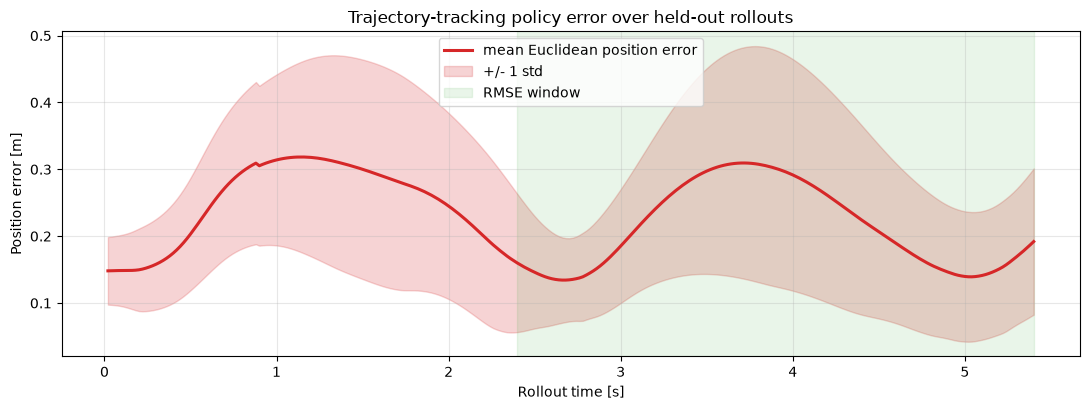

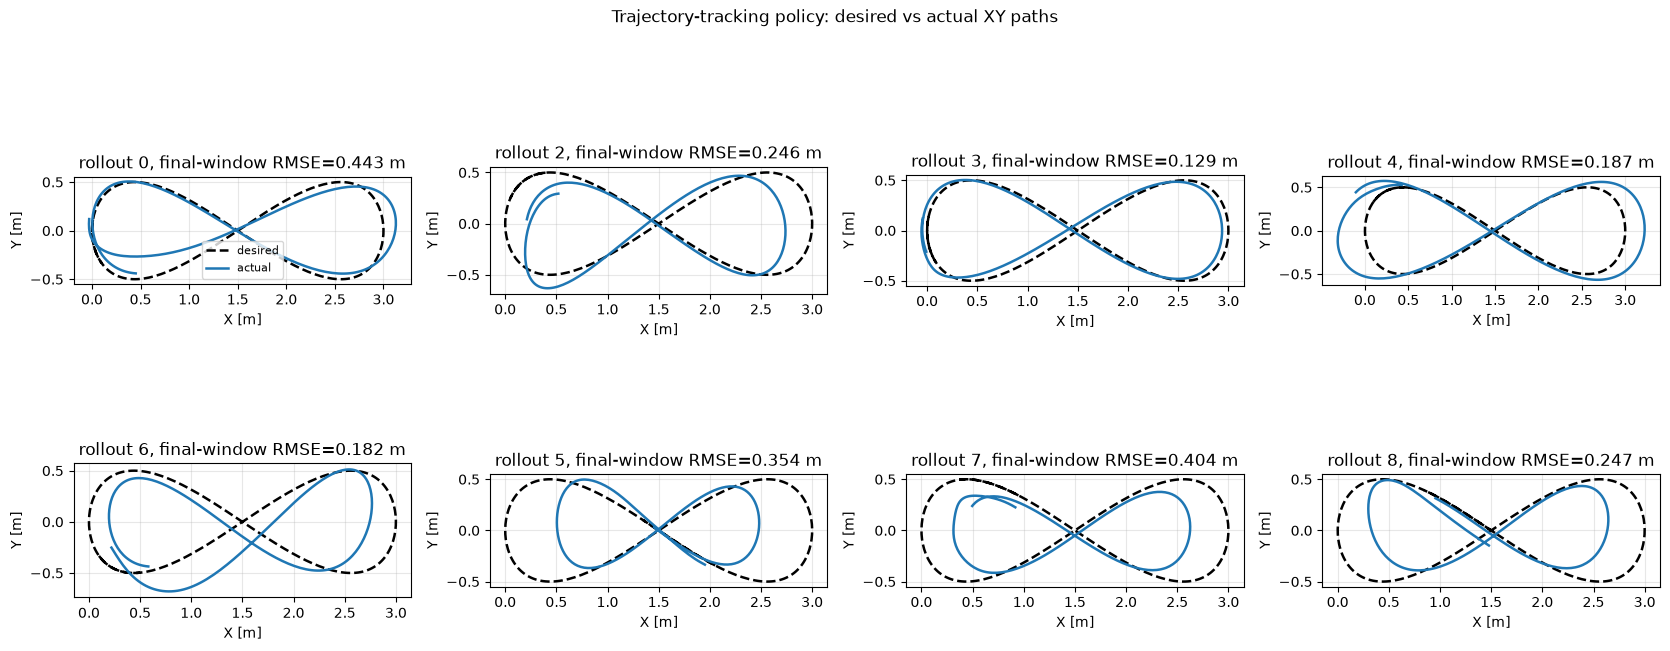

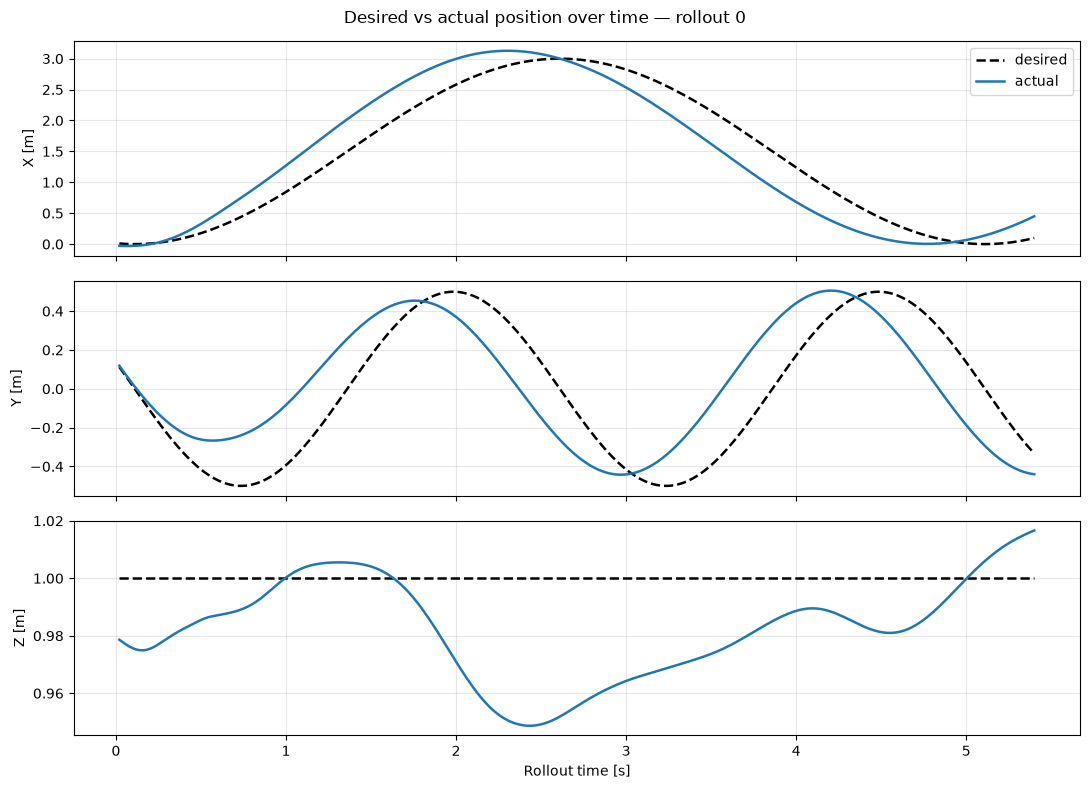

In [19]:
policy_time = sim_dt * (jnp.arange(validation_num_steps) + 1)
policy_successor_states = jax.tree.map(
    lambda leaf: leaf[:, 1:], validation_states
)
policy_positions = policy_successor_states.quadrotor_state.p
policy_reference_rows = reference_rows_for_states(policy_successor_states)
policy_reference_positions = policy_reference_rows[..., TrajColumns.POS.slice]
policy_position_errors = jnp.linalg.norm(
    policy_positions - policy_reference_positions, axis=-1
)
policy_last_window_start = validation_duration - last_policy_window_seconds
policy_last_window = policy_time >= policy_last_window_start
policy_last_window_mask = (
    validation_valid_transition & policy_last_window[None, :]
)
policy_last_window_counts = policy_last_window_mask.sum(axis=1)
per_rollout_policy_rmse = jnp.where(
    policy_last_window_counts > 0,
    jnp.sqrt(
        jnp.sum(
            jnp.where(
                policy_last_window_mask,
                jnp.square(policy_position_errors),
                0.0,
            ),
            axis=1,
        )
        / jnp.maximum(policy_last_window_counts, 1)
    ),
    jnp.nan,
)

host_policy_rmse = np.asarray(jax.device_get(per_rollout_policy_rmse))
eligible_policy_rmse = host_policy_rmse[np.isfinite(host_policy_rmse)]
mean_policy_rmse = (
    eligible_policy_rmse.mean() if eligible_policy_rmse.size else np.nan
)
std_policy_rmse = (
    eligible_policy_rmse.std() if eligible_policy_rmse.size else np.nan
)
print(
    f"Policy position RMSE in final {last_policy_window_seconds:.1f} s: "
    f"{mean_policy_rmse:.6e} +/- {std_policy_rmse:.6e} m"
)
print(
    f"Eligible rollouts in final window: "
    f"{eligible_policy_rmse.size}/{validation_num_rollouts}"
)

host_policy_time = np.asarray(jax.device_get(policy_time))
host_policy_positions = np.asarray(jax.device_get(policy_positions))
host_policy_references = np.asarray(jax.device_get(
    policy_reference_positions
))
host_policy_errors = np.asarray(jax.device_get(policy_position_errors))
host_policy_valid = np.asarray(jax.device_get(
    validation_valid_transition
))
masked_policy_errors = np.where(
    host_policy_valid, host_policy_errors, np.nan
)
mean_policy_error = np.nanmean(masked_policy_errors, axis=0)
std_policy_error = np.nanstd(masked_policy_errors, axis=0)

fig, axis = plt.subplots(figsize=(11, 4.2))
axis.plot(
    host_policy_time, mean_policy_error, color="C3", linewidth=2.2,
    label="mean Euclidean position error",
)
axis.fill_between(
    host_policy_time,
    mean_policy_error - std_policy_error,
    mean_policy_error + std_policy_error,
    color="C3", alpha=0.2, label="+/- 1 std",
)
axis.axvspan(
    policy_last_window_start, validation_duration,
    color="C2", alpha=0.1, label="RMSE window",
)
axis.set_xlabel("Rollout time [s]")
axis.set_ylabel("Position error [m]")
axis.set_title("Trajectory-tracking policy error over held-out rollouts")
axis.grid(True, alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()

policy_plot_indices = np.argsort(
    -np.asarray(jax.device_get(valid_steps_per_rollout))
)[:min(max_policy_trajectory_plots, validation_num_rollouts)]
num_policy_plots = len(policy_plot_indices)
num_plot_columns = min(4, num_policy_plots)
num_plot_rows = (num_policy_plots + num_plot_columns - 1) // num_plot_columns
fig, axes = plt.subplots(
    num_plot_rows, num_plot_columns,
    figsize=(4.2 * num_plot_columns, 3.7 * num_plot_rows),
    squeeze=False,
)
for plot_index, rollout_id in enumerate(policy_plot_indices):
    axis = axes.ravel()[plot_index]
    valid = host_policy_valid[rollout_id]
    axis.plot(
        host_policy_references[rollout_id, valid, 0],
        host_policy_references[rollout_id, valid, 1],
        color="black", linestyle="--", linewidth=1.8, label="desired",
    )
    axis.plot(
        host_policy_positions[rollout_id, valid, 0],
        host_policy_positions[rollout_id, valid, 1],
        color="C0", linewidth=1.8, label="actual",
    )
    axis.set_title(
        f"rollout {rollout_id}, final-window "
        f"RMSE={host_policy_rmse[rollout_id]:.3f} m"
    )
    axis.set_xlabel("X [m]")
    axis.set_ylabel("Y [m]")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.3)
for unused_axis in axes.ravel()[num_policy_plots:]:
    unused_axis.set_visible(False)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Trajectory-tracking policy: desired vs actual XY paths")
fig.tight_layout()
plt.show()

representative_policy_rollout = int(policy_plot_indices[0])
representative_policy_valid = host_policy_valid[representative_policy_rollout]
coordinate_names = ("X", "Y", "Z")
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for coordinate, axis in enumerate(axes):
    axis.plot(
        host_policy_time,
        np.where(
            representative_policy_valid,
            host_policy_references[
                representative_policy_rollout, :, coordinate
            ],
            np.nan,
        ),
        color="black", linestyle="--", linewidth=1.8, label="desired",
    )
    axis.plot(
        host_policy_time,
        np.where(
            representative_policy_valid,
            host_policy_positions[
                representative_policy_rollout, :, coordinate
            ],
            np.nan,
        ),
        color="C0", linewidth=1.8, label="actual",
    )
    axis.set_ylabel(f"{coordinate_names[coordinate]} [m]")
    axis.grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel("Rollout time [s]")
fig.suptitle(
    f"Desired vs actual position over time — rollout "
    f"{representative_policy_rollout}"
)
fig.tight_layout()
plt.show()


## 6. Five-second recursive open-loop residual-dynamics validation

One latent is inferred from each measured initial context and held fixed for that rollout. Starting from the exact measured simulator state at the end of the context, the nominal tracking simulator recursively replays the same recorded action sequence and random keys. After each nominal step, the learned physical position, velocity, and local orientation corrections are applied. There is no teacher forcing or ground-truth state feedback.


In [20]:
open_loop_context_valid = validation_valid_transition[
    :, :context_length
].all(axis=1)
open_loop_available_steps = validation_valid_transition[
    :, context_length:context_length + open_loop_horizon
].sum(axis=1)
open_loop_eligible = (
    open_loop_context_valid & (open_loop_available_steps > 0)
)
if not bool(jnp.any(open_loop_eligible)):
    raise ValueError(
        "No validation rollout survived the 20-step encoder context. "
        "Residual open-loop validation cannot be performed."
    )

open_loop_rollout_indices = jnp.flatnonzero(open_loop_eligible)
open_loop_valid_mask = validation_valid_transition[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
open_loop_initial_states = jax.tree.map(
    lambda leaf: leaf[open_loop_rollout_indices, context_length],
    validation_states,
)
open_loop_initial_contexts = validation_normalized_state_actions[
    open_loop_rollout_indices, :context_length
]
open_loop_actions = validation_actions[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
open_loop_keys = validation_step_keys[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
open_loop_true_env_states = jax.tree.map(
    lambda leaf: leaf[
        open_loop_rollout_indices,
        context_length + 1:context_length + open_loop_horizon + 1,
    ],
    validation_states,
)
open_loop_true_states = open_loop_true_env_states.quadrotor_state
open_loop_reference_positions = reference_rows_for_states(
    open_loop_true_env_states
)[..., TrajColumns.POS.slice]
open_loop_winds = validation_winds[open_loop_rollout_indices]
open_loop_time = sim_dt * (jnp.arange(open_loop_horizon) + 1)

print(f"Eligible open-loop rollouts: {open_loop_rollout_indices.shape[0]}")
print(
    f"Rollouts valid through {open_loop_validation_time:.1f} s: "
    f"{int(open_loop_valid_mask[:, -1].sum())}"
)


Eligible open-loop rollouts: 32
Rollouts valid through 5.0 s: 31


Mean open-loop position RMSE across rollouts: 8.462253e-03 +/- 5.101649e-03 m
Per-rollout cumulative Euclidean position dynamics error:
  rollout 00: valid_steps=250, wind=(+1.41, +1.41, +0.00) m/s^2, cumulative_error=1.847650e+00 m, RMSE=9.353148e-03 m
  rollout 01: valid_steps= 24, wind=(-2.00, -0.00, +0.00) m/s^2, cumulative_error=2.763181e-03 m, RMSE=1.452971e-04 m
  rollout 02: valid_steps=250, wind=(+0.00, -2.00, +0.00) m/s^2, cumulative_error=1.383476e+00 m, RMSE=7.356410e-03 m
  rollout 03: valid_steps=250, wind=(-1.00, -0.00, +0.00) m/s^2, cumulative_error=1.822469e+00 m, RMSE=9.615162e-03 m
  rollout 04: valid_steps=250, wind=(-0.71, +0.71, +0.00) m/s^2, cumulative_error=1.420273e+00 m, RMSE=7.582974e-03 m
  rollout 05: valid_steps=250, wind=(+1.00, +0.00, +0.00) m/s^2, cumulative_error=1.014206e+00 m, RMSE=5.443368e-03 m
  rollout 06: valid_steps=250, wind=(+0.00, -1.00, +0.00) m/s^2, cumulative_error=2.005418e+00 m, RMSE=1.070749e-02 m
  rollout 07: valid_steps=250, wind=(+

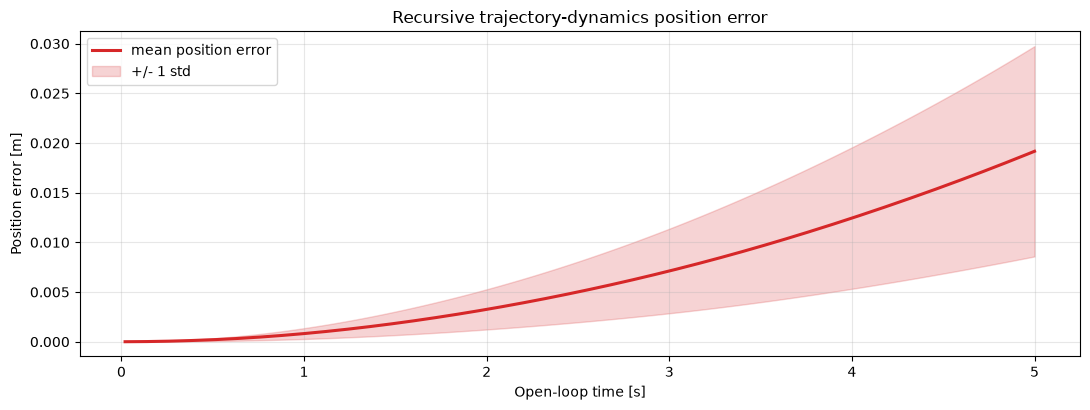

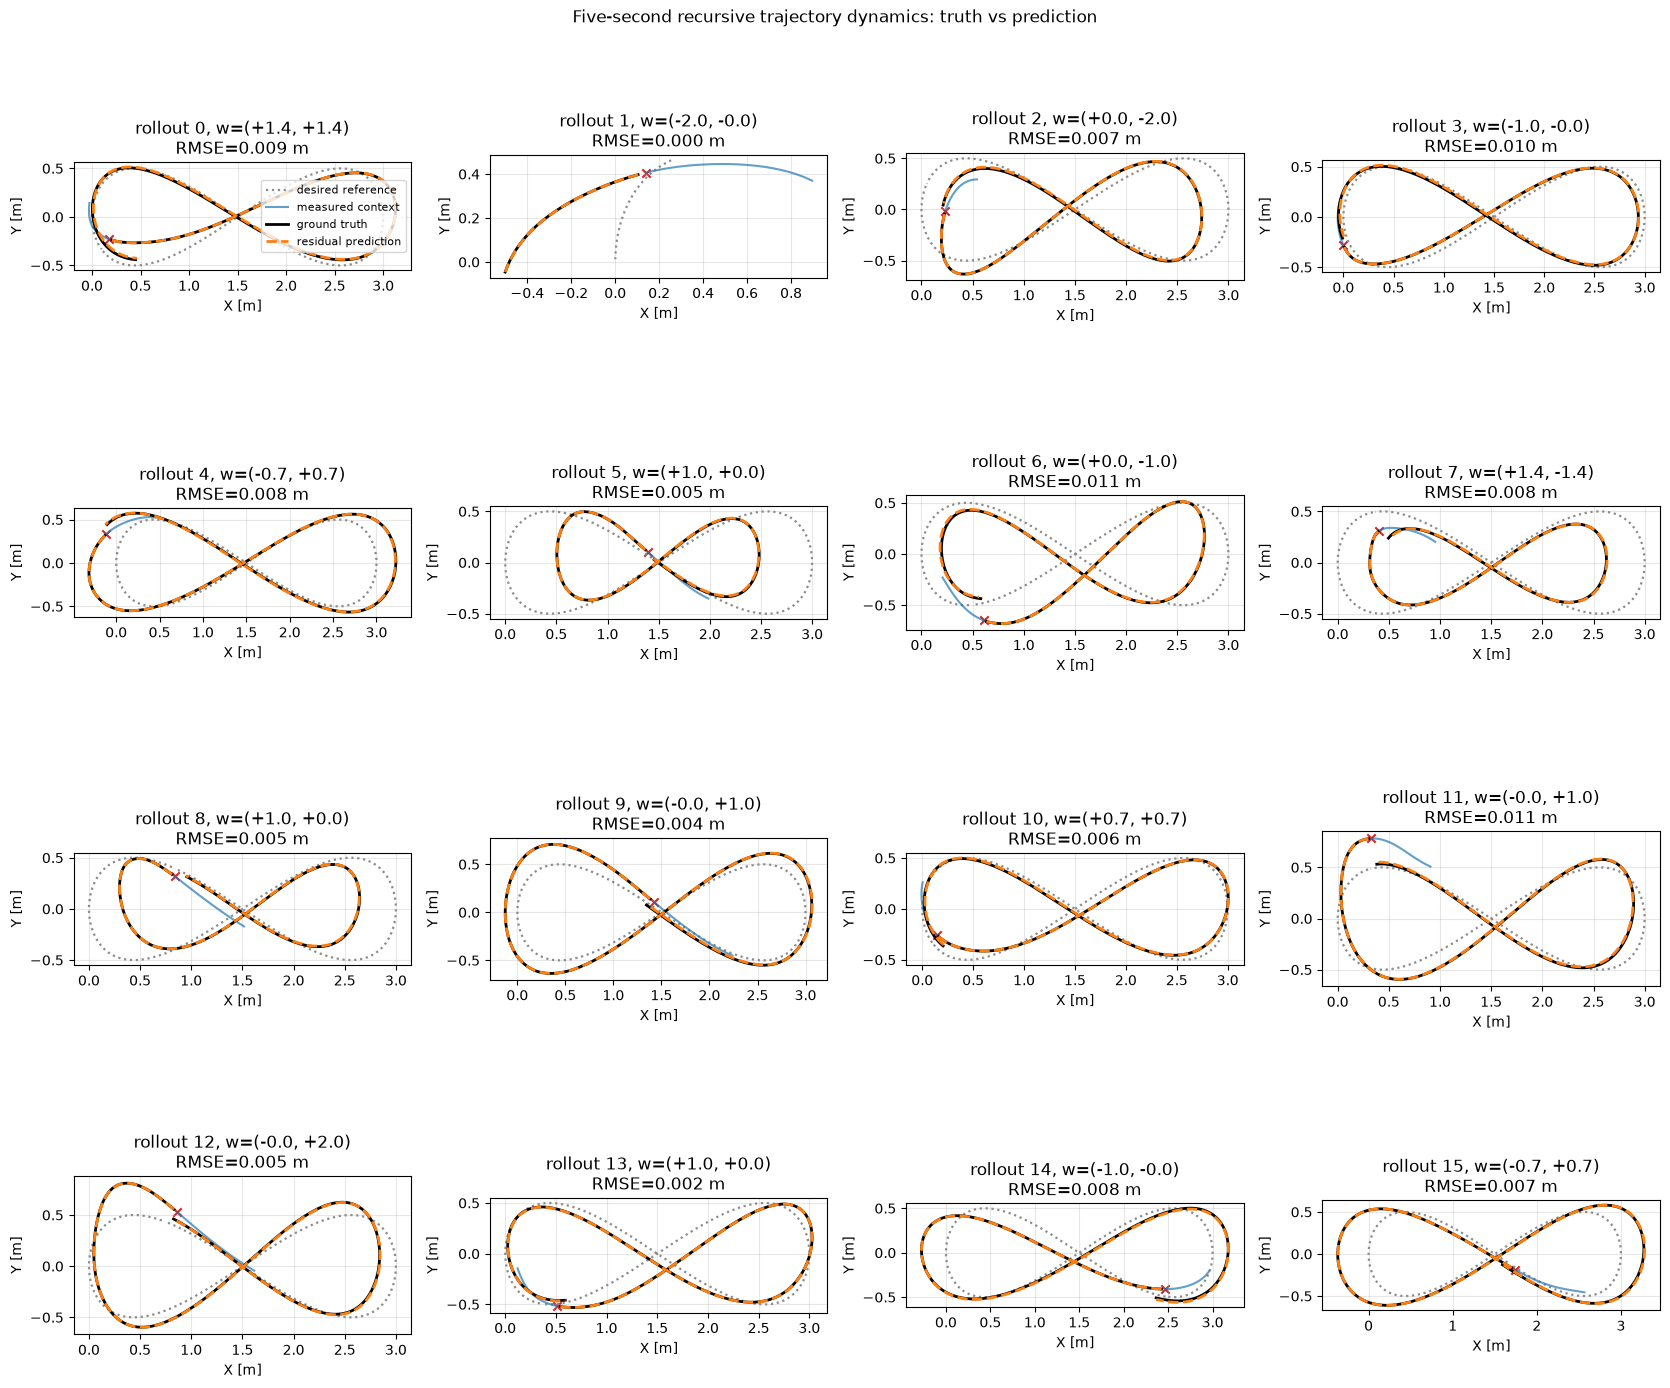

In [21]:
def learned_open_loop(
    initial_state, initial_context, action_sequence, step_keys
):
    fixed_latent = trajectory_encoder.apply(
        joint_params["encoder"], initial_context
    )

    def learned_step(predicted_state, step_inputs):
        action, step_key = step_inputs
        raw_state_action = jnp.concatenate(
            [state_vector_from_env_state(predicted_state), action],
            axis=-1,
        )
        normalized_state_action = normalize_state_actions(
            raw_state_action
        )
        nominal_transition = nominal_env._env._step(
            predicted_state, action, dummy_residual_params, step_key
        )
        normalized_residual = residual_model.apply(
            joint_params["residual"],
            normalized_state_action,
            fixed_latent,
        )
        physical_residual = (
            normalized_residual * residual_target_std
            + residual_target_mean
        )
        nominal_quad_state = nominal_transition.state.quadrotor_state
        corrected_rotation = (
            nominal_quad_state.R
            @ rotation_matrix_from_rotvec(physical_residual[6:9])
        )
        corrected_quad_state = nominal_quad_state.replace(
            p=nominal_quad_state.p + physical_residual[:3],
            v=nominal_quad_state.v + physical_residual[3:6],
            R=corrected_rotation,
        )
        corrected_state = nominal_transition.state.replace(
            quadrotor_state=corrected_quad_state
        )
        return corrected_state, (corrected_quad_state, physical_residual)

    _, (predicted_states, predicted_residuals) = jax.lax.scan(
        learned_step,
        initial_state,
        (action_sequence, step_keys),
    )
    return predicted_states, predicted_residuals, fixed_latent


evaluate_learned_open_loop = jax.jit(jax.vmap(learned_open_loop))
(
    open_loop_predicted_states,
    open_loop_predicted_residuals,
    open_loop_latents,
) = evaluate_learned_open_loop(
    open_loop_initial_states,
    open_loop_initial_contexts,
    open_loop_actions,
    open_loop_keys,
)
open_loop_predicted_states.p.block_until_ready()

open_loop_position_error = jnp.linalg.norm(
    open_loop_predicted_states.p - open_loop_true_states.p,
    axis=-1,
)
valid_open_loop_counts = open_loop_valid_mask.sum(axis=1)
per_rollout_cumulative_dynamics_error = jnp.sum(
    jnp.where(open_loop_valid_mask, open_loop_position_error, 0.0),
    axis=1,
)
per_rollout_position_rmse = jnp.sqrt(
    jnp.sum(
        jnp.where(
            open_loop_valid_mask,
            jnp.square(open_loop_position_error),
            0.0,
        ),
        axis=1,
    )
    / jnp.maximum(valid_open_loop_counts, 1)
)
mean_open_loop_rmse = jnp.mean(per_rollout_position_rmse)
std_open_loop_rmse = jnp.std(per_rollout_position_rmse)

print(
    "Mean open-loop position RMSE across rollouts: "
    f"{float(mean_open_loop_rmse):.6e} +/- "
    f"{float(std_open_loop_rmse):.6e} m"
)
print("Per-rollout cumulative Euclidean position dynamics error:")
for local_index, rollout_id in enumerate(open_loop_rollout_indices):
    wind = open_loop_winds[local_index]
    print(
        f"  rollout {int(rollout_id):02d}: "
        f"valid_steps={int(valid_open_loop_counts[local_index]):3d}, "
        f"wind=({float(wind[0]):+.2f}, {float(wind[1]):+.2f}, "
        f"{float(wind[2]):+.2f}) m/s^2, "
        f"cumulative_error="
        f"{float(per_rollout_cumulative_dynamics_error[local_index]):.6e} m, "
        f"RMSE={float(per_rollout_position_rmse[local_index]):.6e} m"
    )

host_open_loop_time = np.asarray(jax.device_get(open_loop_time))
host_open_loop_error = np.asarray(jax.device_get(open_loop_position_error))
host_open_loop_valid = np.asarray(jax.device_get(open_loop_valid_mask))
masked_open_loop_error = np.where(
    host_open_loop_valid, host_open_loop_error, np.nan
)
mean_open_loop_error = np.nanmean(masked_open_loop_error, axis=0)
std_open_loop_error = np.nanstd(masked_open_loop_error, axis=0)
fig, axis = plt.subplots(figsize=(11, 4.2))
axis.plot(
    host_open_loop_time, mean_open_loop_error,
    color="C3", linewidth=2.2, label="mean position error",
)
axis.fill_between(
    host_open_loop_time,
    mean_open_loop_error - std_open_loop_error,
    mean_open_loop_error + std_open_loop_error,
    color="C3", alpha=0.2, label="+/- 1 std",
)
axis.set_xlabel("Open-loop time [s]")
axis.set_ylabel("Position error [m]")
axis.set_title("Recursive trajectory-dynamics position error")
axis.grid(True, alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()

num_open_loop_plots = min(
    max_open_loop_trajectory_plots,
    int(open_loop_rollout_indices.shape[0]),
)
num_plot_columns = min(4, num_open_loop_plots)
num_plot_rows = (
    num_open_loop_plots + num_plot_columns - 1
) // num_plot_columns
fig, axes = plt.subplots(
    num_plot_rows,
    num_plot_columns,
    figsize=(4.2 * num_plot_columns, 3.7 * num_plot_rows),
    squeeze=False,
)
flat_axes = axes.ravel()
for plot_index in range(num_open_loop_plots):
    axis = flat_axes[plot_index]
    rollout_id = int(open_loop_rollout_indices[plot_index])
    context_positions = np.asarray(jax.device_get(
        validation_quad_states.p[
            rollout_id, :context_length + 1
        ]
    ))
    true_positions = np.asarray(jax.device_get(
        open_loop_true_states.p[plot_index]
    ))
    predicted_positions = np.asarray(jax.device_get(
        open_loop_predicted_states.p[plot_index]
    ))
    desired_positions = np.asarray(jax.device_get(
        open_loop_reference_positions[plot_index]
    ))
    valid_steps = host_open_loop_valid[plot_index]
    wind = np.asarray(jax.device_get(open_loop_winds[plot_index]))

    axis.plot(
        desired_positions[valid_steps, 0],
        desired_positions[valid_steps, 1],
        color="0.55", linestyle=":", linewidth=1.6,
        label="desired reference",
    )
    axis.plot(
        context_positions[:, 0],
        context_positions[:, 1],
        color="C0", alpha=0.7, label="measured context",
    )
    axis.plot(
        true_positions[valid_steps, 0],
        true_positions[valid_steps, 1],
        color="black", linewidth=2.0, label="ground truth",
    )
    axis.plot(
        predicted_positions[valid_steps, 0],
        predicted_positions[valid_steps, 1],
        color="C1", linestyle="--", linewidth=2.0,
        label="residual prediction",
    )
    axis.scatter(
        context_positions[-1, 0], context_positions[-1, 1],
        marker="x", color="C3",
    )
    axis.set_title(
        f"rollout {rollout_id}, "
        f"w=({wind[0]:+.1f}, {wind[1]:+.1f})\n"
        f"RMSE={float(per_rollout_position_rmse[plot_index]):.3f} m"
    )
    axis.set_xlabel("X [m]")
    axis.set_ylabel("Y [m]")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.3)
for unused_axis in flat_axes[num_open_loop_plots:]:
    unused_axis.set_visible(False)
flat_axes[0].legend(fontsize=8)
fig.suptitle(
    "Five-second recursive trajectory dynamics: truth vs prediction"
)
fig.tight_layout()
plt.show()


## 7. Encoder latent-space validation

Every valid rolling context in the fresh figure-eight validation rollouts is encoded in evaluation-only batches. A single centered PCA projection is used for the magnitude and direction panels. Wind labels are never passed to the encoder or dynamics model; they are used only to color the final latent points.


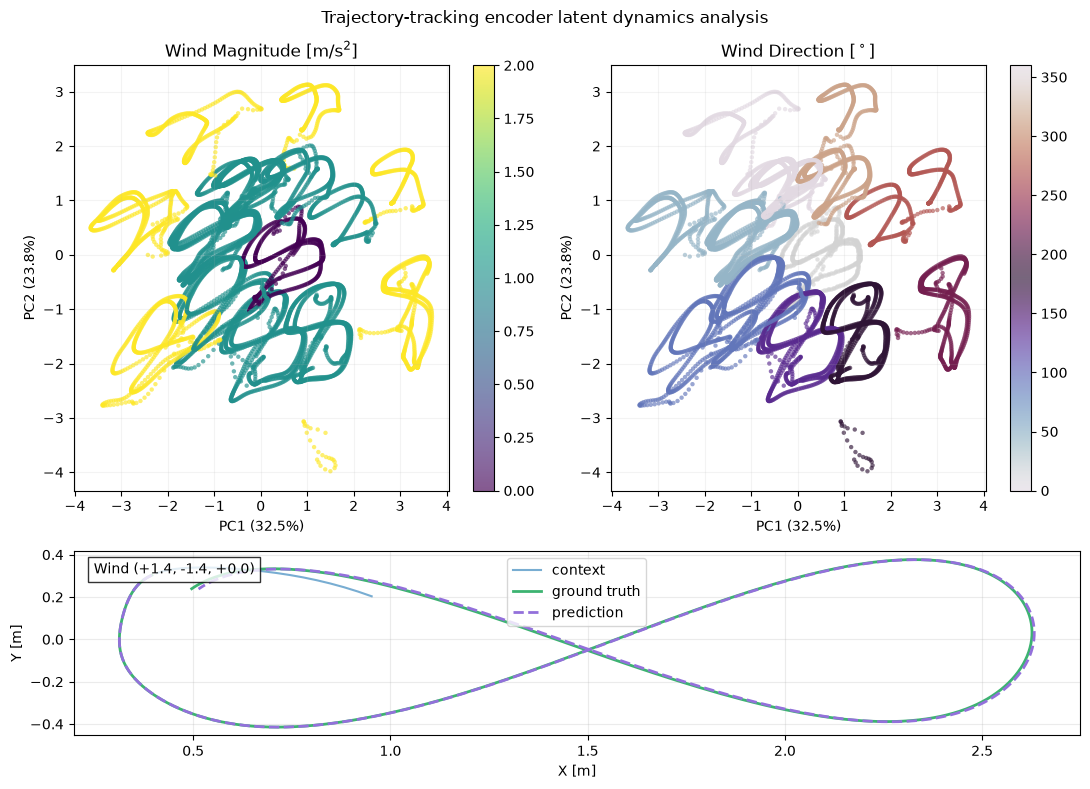

PCA variance explained by PC1 + PC2: 56.30%
Validation context windows encoded: 7,806
Aggregate latent mean/std: -7.557626e-02 / 8.323640e-01
Latent mean and standard deviation per dimension:
  z[00]: mean=-3.009672e-01, std=8.958262e-01
  z[01]: mean=+1.251590e-01, std=7.223513e-01
  z[02]: mean=-2.003352e-01, std=8.038548e-01
  z[03]: mean=-1.021616e-01, std=1.077518e+00
  z[04]: mean=+1.439571e-01, std=9.220346e-01
  z[05]: mean=+3.945902e-02, std=7.690869e-01
  z[06]: mean=-1.470261e-01, std=5.128108e-01
  z[07]: mean=-2.916209e-01, std=6.478649e-01
  z[08]: mean=-5.544755e-02, std=7.925820e-01
  z[09]: mean=-2.202642e-01, std=8.759111e-01
  z[10]: mean=+2.687798e-01, std=8.790786e-01
  z[11]: mean=-1.664476e-01, std=7.219089e-01
Representative rollout: 7, wind=[ 1.414214  -1.4142131  0.       ]


In [22]:
num_encoder_contexts_per_rollout = (
    validation_state_actions.shape[1] - context_length + 1
)
encoder_context_indices = (
    jnp.arange(num_encoder_contexts_per_rollout)[:, None]
    + jnp.arange(context_length)[None, :]
)
encoder_context_valid = validation_valid_transition[
    :, encoder_context_indices
].all(axis=-1)
all_encoder_contexts = validation_normalized_state_actions[
    :, encoder_context_indices
]
encoder_contexts = all_encoder_contexts[encoder_context_valid]
encoder_wind_grid = jnp.broadcast_to(
    validation_winds[:, None, :],
    (
        validation_num_rollouts,
        num_encoder_contexts_per_rollout,
        validation_winds.shape[-1],
    ),
)
encoder_winds = encoder_wind_grid[encoder_context_valid]

if encoder_contexts.shape[0] < 2:
    raise ValueError("At least two valid contexts are required for PCA")


def encode_contexts_in_batches(contexts):
    latent_chunks = []
    for start in range(0, contexts.shape[0], encoder_evaluation_batch_size):
        stop = min(
            start + encoder_evaluation_batch_size,
            contexts.shape[0],
        )
        latent_chunks.append(trajectory_encoder.apply(
            joint_params["encoder"], contexts[start:stop]
        ))
    return jnp.concatenate(latent_chunks, axis=0)


encoder_latents = encode_contexts_in_batches(encoder_contexts)
encoder_latents.block_until_ready()

plot_latents = np.asarray(jax.device_get(encoder_latents))
plot_winds = np.asarray(jax.device_get(encoder_winds))
latent_mean = plot_latents.mean(axis=0, keepdims=True)
centered_latents = plot_latents - latent_mean
_, singular_values, pca_directions = np.linalg.svd(
    centered_latents, full_matrices=False
)
latent_2d = centered_latents @ pca_directions[:2].T
pca_variance = singular_values**2
explained_variance = pca_variance / max(
    pca_variance.sum(), 1e-12
)

wind_magnitude = np.linalg.norm(plot_winds, axis=-1)
nonzero_wind = wind_magnitude > 1e-8
wind_direction = (
    np.degrees(np.arctan2(plot_winds[:, 1], plot_winds[:, 0]))
    % 360.0
)

desired_representative_wind = np.asarray([2.0, -2.0, 0.0])
host_open_loop_winds = np.asarray(jax.device_get(open_loop_winds))
representative_index = int(np.argmin(np.linalg.norm(
    host_open_loop_winds
    - desired_representative_wind[None, :],
    axis=-1,
)))
representative_rollout_id = int(
    open_loop_rollout_indices[representative_index]
)
representative_valid = np.asarray(jax.device_get(
    open_loop_valid_mask[representative_index]
))
representative_context_xy = np.asarray(jax.device_get(
    validation_quad_states.p[
        representative_rollout_id, :context_length + 1, :2
    ]
))
representative_true_xy = np.asarray(jax.device_get(
    open_loop_true_states.p[representative_index, :, :2]
))
representative_predicted_xy = np.asarray(jax.device_get(
    open_loop_predicted_states.p[representative_index, :, :2]
))
representative_wind = host_open_loop_winds[representative_index]

fig = plt.figure(figsize=(11, 8))
grid = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.3])
magnitude_axis = fig.add_subplot(grid[0, 0])
direction_axis = fig.add_subplot(grid[0, 1])
trajectory_axis = fig.add_subplot(grid[1, :])

magnitude_points = magnitude_axis.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=wind_magnitude,
    cmap="viridis",
    s=10,
    alpha=0.65,
    linewidths=0.0,
)
magnitude_axis.set_title(r"Wind Magnitude [$\mathrm{m/s^2}$]")
fig.colorbar(magnitude_points, ax=magnitude_axis)

direction_axis.scatter(
    latent_2d[~nonzero_wind, 0],
    latent_2d[~nonzero_wind, 1],
    color="lightgrey",
    s=10,
    alpha=0.65,
    linewidths=0.0,
)
direction_points = direction_axis.scatter(
    latent_2d[nonzero_wind, 0],
    latent_2d[nonzero_wind, 1],
    c=wind_direction[nonzero_wind],
    cmap="twilight",
    vmin=0.0,
    vmax=360.0,
    s=10,
    alpha=0.65,
    linewidths=0.0,
)
direction_axis.set_title(r"Wind Direction [$^\circ$]")
fig.colorbar(direction_points, ax=direction_axis)

for axis in (magnitude_axis, direction_axis):
    axis.set_xlabel(f"PC1 ({100.0 * explained_variance[0]:.1f}%)")
    axis.set_ylabel(f"PC2 ({100.0 * explained_variance[1]:.1f}%)")
    axis.grid(True, alpha=0.15)

trajectory_axis.plot(
    representative_context_xy[:, 0],
    representative_context_xy[:, 1],
    color="C0",
    alpha=0.6,
    linewidth=1.5,
    label="context",
)
trajectory_axis.plot(
    representative_true_xy[representative_valid, 0],
    representative_true_xy[representative_valid, 1],
    color="mediumseagreen",
    linewidth=2.0,
    label="ground truth",
)
trajectory_axis.plot(
    representative_predicted_xy[representative_valid, 0],
    representative_predicted_xy[representative_valid, 1],
    color="mediumpurple",
    linestyle="--",
    linewidth=2.0,
    label="prediction",
)
trajectory_axis.text(
    0.02,
    0.88,
    f"Wind ({representative_wind[0]:+.1f}, "
    f"{representative_wind[1]:+.1f}, "
    f"{representative_wind[2]:+.1f})",
    transform=trajectory_axis.transAxes,
    bbox={"facecolor": "white", "alpha": 0.8},
)
trajectory_axis.set_xlabel("X [m]")
trajectory_axis.set_ylabel("Y [m]")
trajectory_axis.grid(True, alpha=0.25)
trajectory_axis.legend()

fig.suptitle("Trajectory-tracking encoder latent dynamics analysis")
fig.tight_layout()
plt.show()

print(
    "PCA variance explained by PC1 + PC2: "
    f"{100.0 * explained_variance[:2].sum():.2f}%"
)
print(f"Validation context windows encoded: {plot_latents.shape[0]:,}")
print(
    f"Aggregate latent mean/std: "
    f"{plot_latents.mean():+.6e} / {plot_latents.std():.6e}"
)
print("Latent mean and standard deviation per dimension:")
for latent_index, (dimension_mean, dimension_std) in enumerate(zip(
    plot_latents.mean(axis=0), plot_latents.std(axis=0)
)):
    print(
        f"  z[{latent_index:02d}]: mean={dimension_mean:+.6e}, "
        f"std={dimension_std:.6e}"
    )
print(
    f"Representative rollout: {representative_rollout_id}, "
    f"wind={representative_wind}"
)


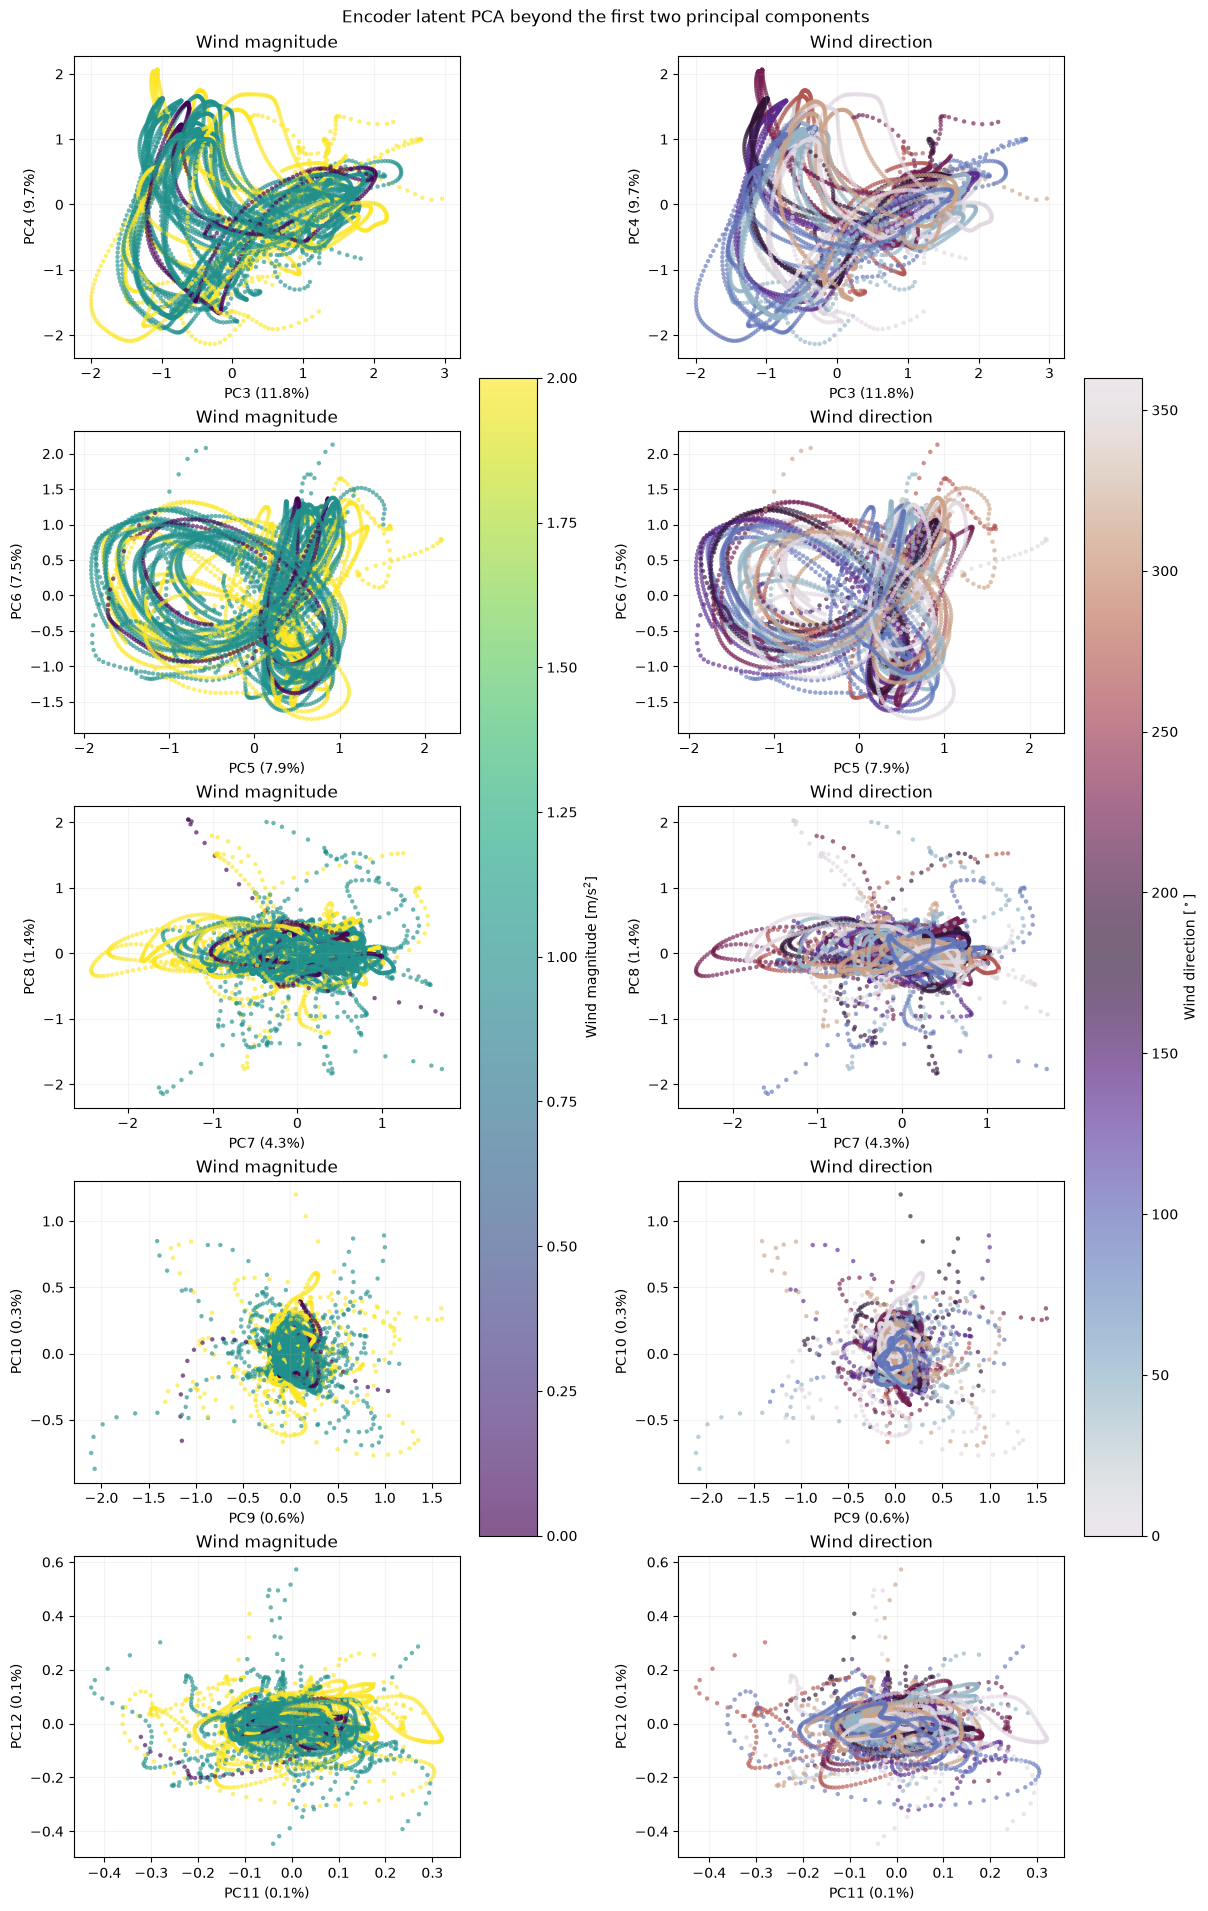

Higher principal-component variance summary:
  PC3-PC4: 21.56%
  PC5-PC6: 15.38%
  PC7-PC8: 5.68%
  PC9-PC10: 0.90%
  PC11-PC12: 0.17%


In [23]:
# Inspect the remaining principal components in consecutive 2-D pairs.
# This uses the exact centered latents and PCA basis fitted in Section 7.
full_pca_latents = centered_latents @ pca_directions.T
num_available_pcs = min(
    full_pca_latents.shape[1], explained_variance.shape[0]
)
higher_pc_pairs = list(zip(
    range(2, num_available_pcs, 2),
    range(3, num_available_pcs, 2),
))
if not higher_pc_pairs:
    raise ValueError("No principal-component pairs beyond PC1-PC2")

wind_magnitude_min = float(wind_magnitude.min())
wind_magnitude_max = float(wind_magnitude.max())
if np.isclose(wind_magnitude_min, wind_magnitude_max):
    wind_magnitude_max = wind_magnitude_min + 1e-8

fig, axes = plt.subplots(
    len(higher_pc_pairs),
    2,
    figsize=(12, 3.8 * len(higher_pc_pairs)),
    squeeze=False,
    constrained_layout=True,
)
magnitude_points = None
direction_points = None
for row_index, (horizontal_pc, vertical_pc) in enumerate(
    higher_pc_pairs
):
    magnitude_axis, direction_axis = axes[row_index]
    magnitude_points = magnitude_axis.scatter(
        full_pca_latents[:, horizontal_pc],
        full_pca_latents[:, vertical_pc],
        c=wind_magnitude,
        cmap="viridis",
        vmin=wind_magnitude_min,
        vmax=wind_magnitude_max,
        s=10,
        alpha=0.65,
        linewidths=0.0,
    )
    direction_axis.scatter(
        full_pca_latents[~nonzero_wind, horizontal_pc],
        full_pca_latents[~nonzero_wind, vertical_pc],
        color="lightgrey",
        s=10,
        alpha=0.65,
        linewidths=0.0,
    )
    if np.any(nonzero_wind):
        direction_points = direction_axis.scatter(
            full_pca_latents[nonzero_wind, horizontal_pc],
            full_pca_latents[nonzero_wind, vertical_pc],
            c=wind_direction[nonzero_wind],
            cmap="twilight",
            vmin=0.0,
            vmax=360.0,
            s=10,
            alpha=0.65,
            linewidths=0.0,
        )

    horizontal_label = (
        f"PC{horizontal_pc + 1} "
        f"({100.0 * explained_variance[horizontal_pc]:.1f}%)"
    )
    vertical_label = (
        f"PC{vertical_pc + 1} "
        f"({100.0 * explained_variance[vertical_pc]:.1f}%)"
    )
    magnitude_axis.set_title("Wind magnitude")
    direction_axis.set_title("Wind direction")
    for axis in (magnitude_axis, direction_axis):
        axis.set_xlabel(horizontal_label)
        axis.set_ylabel(vertical_label)
        axis.grid(True, alpha=0.15)

fig.colorbar(
    magnitude_points,
    ax=axes[:, 0].tolist(),
    label=r"Wind magnitude [$\mathrm{m/s^2}$]",
    shrink=0.9,
)
if direction_points is not None:
    fig.colorbar(
        direction_points,
        ax=axes[:, 1].tolist(),
        label=r"Wind direction [$^\circ$]",
        shrink=0.9,
    )
fig.suptitle(
    "Encoder latent PCA beyond the first two principal components"
)
plt.show()

print("Higher principal-component variance summary:")
for horizontal_pc, vertical_pc in higher_pc_pairs:
    print(
        f"  PC{horizontal_pc + 1}-PC{vertical_pc + 1}: "
        f"{100.0 * (explained_variance[horizontal_pc] + explained_variance[vertical_pc]):.2f}%"
    )


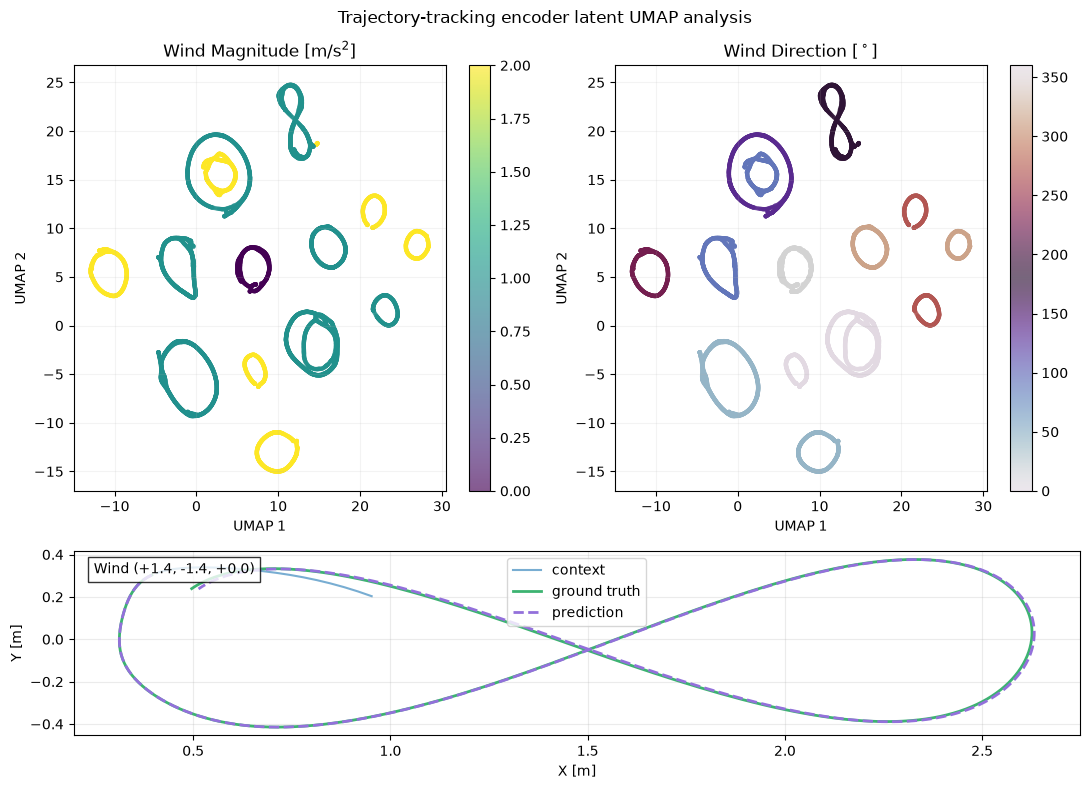

Validation context windows embedded: 7,806
UMAP configuration: n_neighbors=30, min_dist=0.1, metric=euclidean, seed=2026
Representative rollout: 7, wind=[ 1.414214  -1.4142131  0.       ]


In [24]:
# UMAP view of the exact validation latents plotted by the PCA cell above.
# Wind labels affect only point colors; they are not inputs to UMAP.
try:
    from umap import UMAP
except ImportError as error:
    raise ImportError(
        "This cell requires umap-learn. Install it in the active "
        "kernel with: pip install umap-learn"
    ) from error

if plot_latents.shape[0] < 3:
    raise ValueError("At least three encoded contexts are required for UMAP")

umap_n_neighbors = min(30, plot_latents.shape[0] - 1)
umap_min_dist = 0.1
umap_metric = "euclidean"
umap_reducer = UMAP(
    n_components=2,
    n_neighbors=umap_n_neighbors,
    min_dist=umap_min_dist,
    metric=umap_metric,
    random_state=seed,
    transform_seed=seed,
    n_jobs=1,
    low_memory=True,
)
umap_latent_2d = umap_reducer.fit_transform(plot_latents)

fig = plt.figure(figsize=(11, 8))
grid = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.3])
magnitude_axis = fig.add_subplot(grid[0, 0])
direction_axis = fig.add_subplot(grid[0, 1])
trajectory_axis = fig.add_subplot(grid[1, :])

magnitude_points = magnitude_axis.scatter(
    umap_latent_2d[:, 0],
    umap_latent_2d[:, 1],
    c=wind_magnitude,
    cmap="viridis",
    s=10,
    alpha=0.65,
    linewidths=0.0,
)
magnitude_axis.set_title(r"Wind Magnitude [$\mathrm{m/s^2}$]")
fig.colorbar(magnitude_points, ax=magnitude_axis)

direction_axis.scatter(
    umap_latent_2d[~nonzero_wind, 0],
    umap_latent_2d[~nonzero_wind, 1],
    color="lightgrey",
    s=10,
    alpha=0.65,
    linewidths=0.0,
)
direction_points = direction_axis.scatter(
    umap_latent_2d[nonzero_wind, 0],
    umap_latent_2d[nonzero_wind, 1],
    c=wind_direction[nonzero_wind],
    cmap="twilight",
    vmin=0.0,
    vmax=360.0,
    s=10,
    alpha=0.65,
    linewidths=0.0,
)
direction_axis.set_title(r"Wind Direction [$^\circ$]")
fig.colorbar(direction_points, ax=direction_axis)

for axis in (magnitude_axis, direction_axis):
    axis.set_xlabel("UMAP 1")
    axis.set_ylabel("UMAP 2")
    axis.grid(True, alpha=0.15)

trajectory_axis.plot(
    representative_context_xy[:, 0],
    representative_context_xy[:, 1],
    color="C0",
    alpha=0.6,
    linewidth=1.5,
    label="context",
)
trajectory_axis.plot(
    representative_true_xy[representative_valid, 0],
    representative_true_xy[representative_valid, 1],
    color="mediumseagreen",
    linewidth=2.0,
    label="ground truth",
)
trajectory_axis.plot(
    representative_predicted_xy[representative_valid, 0],
    representative_predicted_xy[representative_valid, 1],
    color="mediumpurple",
    linestyle="--",
    linewidth=2.0,
    label="prediction",
)
trajectory_axis.text(
    0.02,
    0.88,
    f"Wind ({representative_wind[0]:+.1f}, "
    f"{representative_wind[1]:+.1f}, "
    f"{representative_wind[2]:+.1f})",
    transform=trajectory_axis.transAxes,
    bbox={"facecolor": "white", "alpha": 0.8},
)
trajectory_axis.set_xlabel("X [m]")
trajectory_axis.set_ylabel("Y [m]")
trajectory_axis.grid(True, alpha=0.25)
trajectory_axis.legend()

fig.suptitle("Trajectory-tracking encoder latent UMAP analysis")
fig.tight_layout()
plt.show()

print(f"Validation context windows embedded: {plot_latents.shape[0]:,}")
print(
    f"UMAP configuration: n_neighbors={umap_n_neighbors}, "
    f"min_dist={umap_min_dist}, metric={umap_metric}, seed={seed}"
)
print(
    f"Representative rollout: {representative_rollout_id}, "
    f"wind={representative_wind}"
)
